In [1]:
import sys
sys.path
sys.path.append(r"../")
sys.path.append(r'C:\Users\sadiq\Desktop\U_Vienna\codes\icm-zebrafish')
import numpy as np
import matplotlib.pyplot as plt
from d_CSL import *
from new_utils import *
import d_CSL
from tqdm.notebook import tqdm
import seaborn as sns
import pandas as pd
from numba import jit, njit, vectorize


from sklearn.linear_model import LinearRegression

In [2]:
%reload_ext autoreload
%autoreload 2
from d_CSL import *

In [3]:
N_PASTS, n_lags, n_perm = list(range(1, 4)), 1, 10000
alpha, beta = 0.001, 0.0001

In [4]:
def residual(x,z):
    model = LinearRegression(fit_intercept=True)
    model.fit(z.T,x)
    coefs,intercept = model.coef_,model.intercept_
    res = x - np.dot(coefs,z)-intercept
    return res


@jit(nopython=True)
def perm_test_(x, y, shuffle):
    count, corr_1 = 0,np.corrcoef(x,y)[1,0]
    for j in range(shuffle):
        x_copy = np.copy(x)
        np.random.shuffle(x_copy)
        corr_2 = np.corrcoef(x_copy,y)[1,0]
        if np.abs(corr_2) >= np.abs(corr_1):
            count+=1
    return count/shuffle

def correlation_(X,n_perm):
    corr, n = np.abs(np.corrcoef(X)),X.shape[0]
    pVal_corr = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            pVal_corr[i,j] = perm_test_(X[i,:], X[j,:], n_perm)   # perm_test_shift()
    return corr, pVal_corr


def inv_correlation_(X, n_perm):
    n = X.shape[0]
    inv_corr, pVal_inv_corr = np.zeros((n,n)), np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            x,y,z = X[i,:],X[j,:], np.delete(X,[i,j],axis=0)
            x_res,y_res = residual(x,z), residual(y,z)
            inv_corr[i,j],pVal_inv_corr[i,j] = np.abs(np.corrcoef(x_res,y_res)[1,0]), perm_test_(x_res,y_res,n_perm)
    return inv_corr, pVal_inv_corr

def comp(X, n_perm):
    corr, pVal_corr = correlation_(X,n_perm)
    inv_corr, pVal_inv_corr = inv_correlation_(X, n_perm)
    sig_corr,sig_inv = np.multiply(corr,pVal_corr<=alpha), np.multiply(inv_corr,pVal_inv_corr<=beta)
    inf = np.logical_and(sig_corr,sig_inv)
    np.fill_diagonal(inf,0)
    return inf

In [5]:
%%time

# load data
os.chdir(r'./data/Sachs_data/')
names = [n for n in os.listdir() if n.endswith('.xls')]
infs = []
for i in range(len(names)):
    data = pd.read_excel(names[i])
    X_ = data.values
    X = X_.T
    print('Data ' + names[i])
    print('')
    infs.append(comp(X, 10000))

Data 1. cd3cd28.xls



C:\Users\sadiq\AppData\Local\Temp\ipykernel_13780\4263757478.py:11: NumbaExperimentalFeatureWarning: Use of isinstance() detected. This is an experimental feature.
  count, corr_1 = 0,np.corrcoef(x,y)[1,0]


Data 10. cd3cd28icam2+aktinhib.xls

Data 11. cd3cd28icam2+g0076.xls

Data 12. cd3cd28icam2+psit.xls

Data 13. cd3cd28icam2+u0126.xls

Data 14. cd3cd28icam2+ly.xls

Data 2. cd3cd28icam2.xls

Data 3. cd3cd28+aktinhib.xls

Data 4. cd3cd28+g0076.xls

Data 5. cd3cd28+psitect.xls

Data 6. cd3cd28+u0126.xls

Data 7. cd3cd28+ly.xls

Data 8. pma.xls

Data 9. b2camp.xls

CPU times: total: 47min 8s
Wall time: 10min 10s


In [6]:
stop

NameError: name 'stop' is not defined

In [7]:
pro = ['Raf', 'Mek', 'P1cy', 'PIP2', 'PIP3', 'p44/42', 'Akt', 'PKA', 'PKC', 'p38', 'Jnk']

In [8]:
np.transpose(np.where(infs[0]!=0))

array([[ 0,  1],
       [ 1,  0],
       [ 3,  4],
       [ 4,  3],
       [ 5,  6],
       [ 5,  7],
       [ 6,  5],
       [ 6,  7],
       [ 7,  5],
       [ 7,  6],
       [ 8,  9],
       [ 8, 10],
       [ 9,  8],
       [10,  8]], dtype=int64)

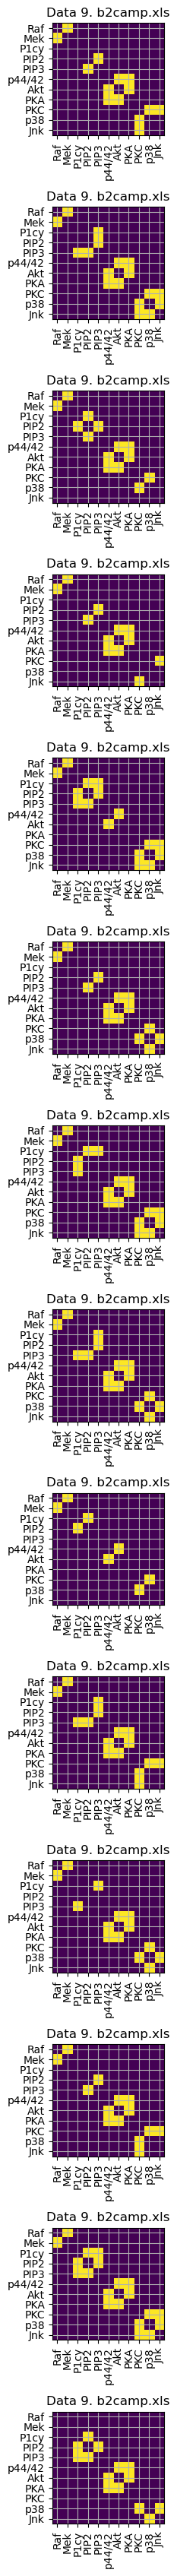

In [10]:

fig,ax = plt.subplots(14,1,figsize=(4,34))
for j in range(14):
    ax[j].imshow(infs[j])
    ax[j].set_title(f'Data {names[i]}')
    ax[j].set_xticks(np.arange(infs[j].shape[0]))
    ax[j].set_yticks(np.arange(infs[j].shape[0]))
    ax[j].set_xticklabels(pro,rotation=90)
    ax[j].set_yticklabels(pro)
    ax[j].grid()
plt.tight_layout()